# Analiza cen smartfonów na Amazon

Do analizy pobrałem rzeczywiste dane cenowe pozyskane przez płatne API Keepa z rynku Amazon US.
Skupiłem się na trzech markach (Apple, Google, Samsung) i łącznie na 63 submodelach.
Do analizy cenowej wykorzystałem 878 000 rekordów cenowych z lat 2019-2026.
Badałem też wielkość sprzedaży na podstawie ponad 18000+ miesięcznych odczytów.

Pytanie jest proste: jak szybko telefon traci wartość po trafieniu na rynek wtórny i czy zależy to od marki, wariantu modelu albo miesiąca? Czy istnieją jakieś wzorce i zależności między markami i submodelami?

**Kilka słów o projekcie**

Dane zostały pobrane z API Keepa mniej więcej w lutym 2026, zapisałem je w lokalnej bazie PostgreSQL i wstępnie badałem przy użyciu SQLa i wizualizacji w Power BI.

Potem projekt odłożyłem na bok i skupiłem się na innych tematach, ale na początku maja postanowiłem zacząć od nowa i zrobić go w Pythonie zarówno jako pozycję do portfolio, jak i projekt na kurs Crappy Data (Python w Analizie Danych). Jakieś 50–60% czasu pochłonęła iteracyjna analiza i eksploracja: testowanie różnych poziomów agregacji, obsługa edge case'ów, korekty podejścia i walka z różnymi problemami. Miałem też kilka większych cofnięć.

Ostatecznie zdecydowałem się na wartości relatywne (% ceny premierowej), ale w analizie uwzględniłem też surowe ceny w USD.

Poniżej przykłady wyzwań, na które natrafiłem:

- Każdy wariant produktu (np. iPhone 14 128GB Red Renewed Premium) miał własny kod ASIN i dane śledzone tylko dla tej konkretnej konfiguracji. Trzeba było to zidentyfikować i przemyśleć sposób agregacji
- Daty w API były podawane jako liczba minut od 2011-01-01 (tzw. KeepaTime)
- Historia cen miała luki między datą premiery a początkiem śledzenia - prawdopodobnie dlatego, że śledzimy rynek wtórny, a nie sprzedaż bezpośrednią
- Ceny były podzielone przez 100
- Pole monthly_sold reprezentuje dolną granicę przedziału sprzedaży, a nie precyzyjną liczbę (np. 50 oznacza 50-99 sztuk). Traktuję je jako wskaźnik względny, ale pozwala to na sensowne porównania między modelami

Analiza dotyczy wyłącznie telefonów z kategorii Renewed. W przypadku Apple mamy dwie klasy: Renewed i Renewed Premium.

Ceny premierowe (official_launch_price) najpierw byly agregowane bezpośrednio z danych, ale ostatecznie zebrałem je z oficjalnych komunikatów prasowych jako średnia cena dla wszystkich wariantów pamięci danego submodelu (np. dla iPhone'a 16 Pro to średnia z wariantów 128 GB, 256 GB itd.).

Najnowsze modele (np. iPhone 17) zostały pominięte ze względu na zbyt krótką historię cenową.

## Import danych i agregacja

Poniżej znajduje się kod użyty do importu i agregacji danych w ostatecznej i uporządkowanej formie. Dla zachowania porządku pominąłem wstępną fazę eksploracji i czyszczenia, która obejmowała wiele iteracji w różnych notebookach. Poniżej przedstawiam już przetworzoną, logiczną strukturę finalnego zbioru danych.

In [1]:
#Imports + wczytanie danych z podglądem

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set_theme(style='whitegrid')

data_folder = '../data/'
for file in os.listdir(data_folder):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)

original_launch_ref = pd.read_csv('../data/official_launch_prices.csv')
ms_df = pd.read_csv('../data/monthly_sold_full.csv')

print(df.head())
print(original_launch_ref.head())
print(ms_df.head())

         asin  storage_gb   color    product_grade submodel_name  brand  \
0  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
1  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
2  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
3  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   
4  B011SDYBZW        64.0  Purple  Renewed Premium     iPhone 11  Apple   

  generation_name premiere_date             datetime  new_price  amazon  \
0       iPhone 11    2019-09-20  2021-07-02 15:36:00       5.69    5.69   
1       iPhone 11    2019-09-20  2021-07-09 18:36:00       5.51    5.51   
2       iPhone 11    2019-09-20  2021-07-23 10:36:00       5.69    5.69   
3       iPhone 11    2019-09-20  2021-07-24 07:36:00       5.29    5.29   
4       iPhone 11    2019-09-20  2021-08-06 09:32:00       5.69    5.69   

   used_price  list_price  sales_rank  count_new  count_used  
0         NaN         NaN         N

In [2]:
# Agregacja danych

df = df.merge(original_launch_ref, on='submodel_name')
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])
df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]
df['NEW'] = df['new_price'] * 100
df = df.drop('new_price', axis=1)
df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7 #required to deal with splitting/duplicated lines on the charts later as there are data points with no equivalents, so they create new lines
df['tier'] = df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
df['tier'] = df['tier'].replace('', 'Base')


# Spadek cen
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')]
base_apple_decay_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
base_samsung_decay_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')]
base_google_decay_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

base_combined_df = df[df['tier'] == 'Base']
all_brands_decay_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()

grouped_generation_decay_df = df.groupby(['submodel_name', 'generation_name', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
iphone13_decay_df = grouped_generation_decay_df[grouped_generation_decay_df['generation_name'] == 'iPhone 13']



# retencja ceny po 1 roku
retention_1yr_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]
retention_1yr_df = retention_1yr_df.groupby('generation_name').agg(
    price_retention=('price_pct_of_launch', 'mean'),
    brand=('brand', 'first')
).reset_index().sort_values('price_retention', ascending=False)

brand_retention_1yr = retention_1yr_df.groupby('brand')['price_retention'].mean()
apple_retention_1yr = brand_retention_1yr['Apple']
samsung_retention_1yr = brand_retention_1yr['Samsung']
google_retention_1yr = brand_retention_1yr['Google']


grade_means = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple')].groupby('product_grade')['price_pct_of_launch'].mean()
renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed']

# ceny premierowe z podziałem na tiery
gen_lookup = df[['submodel_name', 'generation_name', 'brand']].drop_duplicates()
launch_ref = original_launch_ref.copy().merge(gen_lookup, on='submodel_name', how='left')
launch_ref['tier'] = launch_ref.apply(lambda row: row['submodel_name'].replace(str(row['generation_name']), '').strip(), axis=1)
launch_ref['tier'] = launch_ref['tier'].replace('', 'Base')

launch_ref['official_premiere_date'] = pd.to_datetime(launch_ref['official_premiere_date'])
base_launch_ref = launch_ref[launch_ref['tier'] == 'Base']
flagship_launch_ref = launch_ref[(launch_ref['tier'] == 'Pro Max') | (launch_ref['tier'] == 'Ultra') | (launch_ref['tier'] == 'Pro XL') | (launch_ref['tier'] == 'Ultra') | ((launch_ref['tier'] == 'Pro') & (launch_ref['brand'] == 'Google'))]

# agregacja po tierach do analizy spadku cen
all_brands_tier_price_decay_df = df.groupby(['brand', 'tier', 'days_rounded'])['price_pct_of_launch'].mean().reset_index()
apple_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Apple']
samsung_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Samsung']
google_tier_price_decay_df = all_brands_tier_price_decay_df[all_brands_tier_price_decay_df['brand'] == 'Google']


# spadek cen w USD
dollar_all_brands_price_decay_df = df.groupby(['brand', 'submodel_name', 'days_rounded', 'tier'])['NEW'].mean().reset_index()

apple_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Apple') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Pro Max'))]
samsung_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Samsung') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Ultra') | (dollar_all_brands_price_decay_df['tier'] == 'Edge'))]
google_dollar_price_decay_df = dollar_all_brands_price_decay_df[(dollar_all_brands_price_decay_df['brand'] == 'Google') & ((dollar_all_brands_price_decay_df['tier'] == 'Base') | (dollar_all_brands_price_decay_df['tier'] == 'Pro') | (dollar_all_brands_price_decay_df['tier'] == 'Pro Fold'))]



# dane sprzedażowe

ms_df = ms_df.merge(original_launch_ref, on='submodel_name', how='left')
ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])
del ms_df['premiere_date']
ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]
ms_df['tier'] = ms_df.apply(lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(), axis=1)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')


new_ms_df = ms_df.copy().set_index(ms_df['datetime'])
new_ms_df = new_ms_df.groupby('asin').resample('ME').last()
new_ms_df = new_ms_df[(new_ms_df['submodel_name'].notna()) & (new_ms_df['monthly_sold'] >= 0)]

new_ms_df['month_year'] = new_ms_df['datetime'].dt.to_period('M').dt.to_timestamp()

brand_ms_df = new_ms_df.groupby(['brand', 'month_year'])['monthly_sold'].sum().reset_index()
brand_tier_ms_df = new_ms_df.groupby(['brand', 'tier', 'month_year'])['monthly_sold'].sum().reset_index()
submodel_ms_df = new_ms_df.groupby(['brand', 'submodel_name', 'tier', 'generation_name', 'month_year'])['monthly_sold'].sum().reset_index()

apple_base_ms_df = submodel_ms_df[(submodel_ms_df['brand'] == 'Apple') & ((submodel_ms_df['tier'] == 'Base'))]

apple_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Apple') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Pro Max'))]
samsung_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Samsung') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Ultra') | (brand_tier_ms_df['tier'] == 'Edge'))]
google_ms_df = brand_tier_ms_df[(brand_tier_ms_df['brand'] == 'Google') & ((brand_tier_ms_df['tier'] == 'Base') | (brand_tier_ms_df['tier'] == 'Pro') | (brand_tier_ms_df['tier'] == 'Pro Fold'))]

iphone11_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 11']
iphone13_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 13']
iphone15_ms_df = submodel_ms_df[submodel_ms_df['generation_name'] == 'iPhone 15']

---
## Przegląd projektu

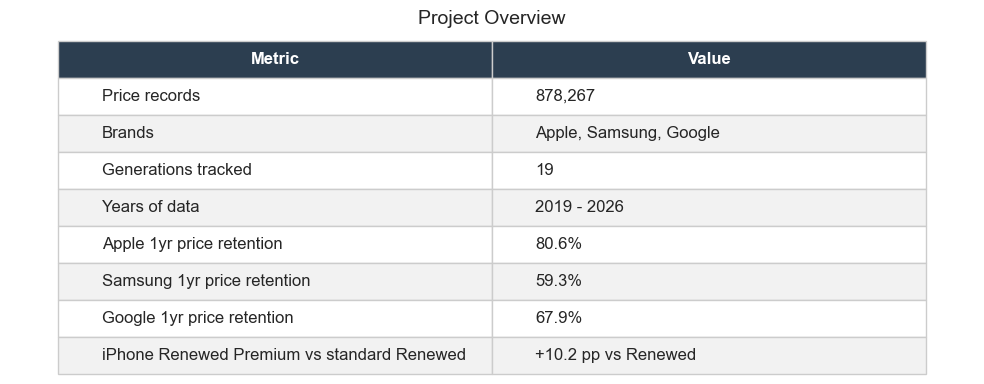

In [3]:
kpi_data = [
    ['Price records', '878,267'],
    ['Brands', 'Apple, Samsung, Google'],
    ['Generations tracked', str(df['generation_name'].nunique())],
    ['Years of data', '2019 - 2026'],
    ['Apple 1yr price retention', f'{round(apple_retention_1yr, 1)}%'],
    ['Samsung 1yr price retention', f'{round(samsung_retention_1yr, 1)}%'],
    ['Google 1yr price retention', f'{round(google_retention_1yr, 1)}%'],
    ['iPhone Renewed Premium vs standard Renewed', f'+{round(renewed_premium_premium, 1)} pp vs Renewed'],
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=kpi_data,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center',
    colWidths=[0.45, 0.45]
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Project Overview', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


---
# Analiza spadku wartości cen

Każdy wykres poniżej pokazuje cenę jako procent ceny początkowej w czasie.
Oś X pokazuje dni od premiery, dzięki czemu modele można porównywać w tym samym momencie cyklu niezależnie od daty wydania.

## Oficjalne ceny premierowe
Ceny premierowe zostały obliczone jako średnia dla wszystkich wariantów pamięci danego submodelu.

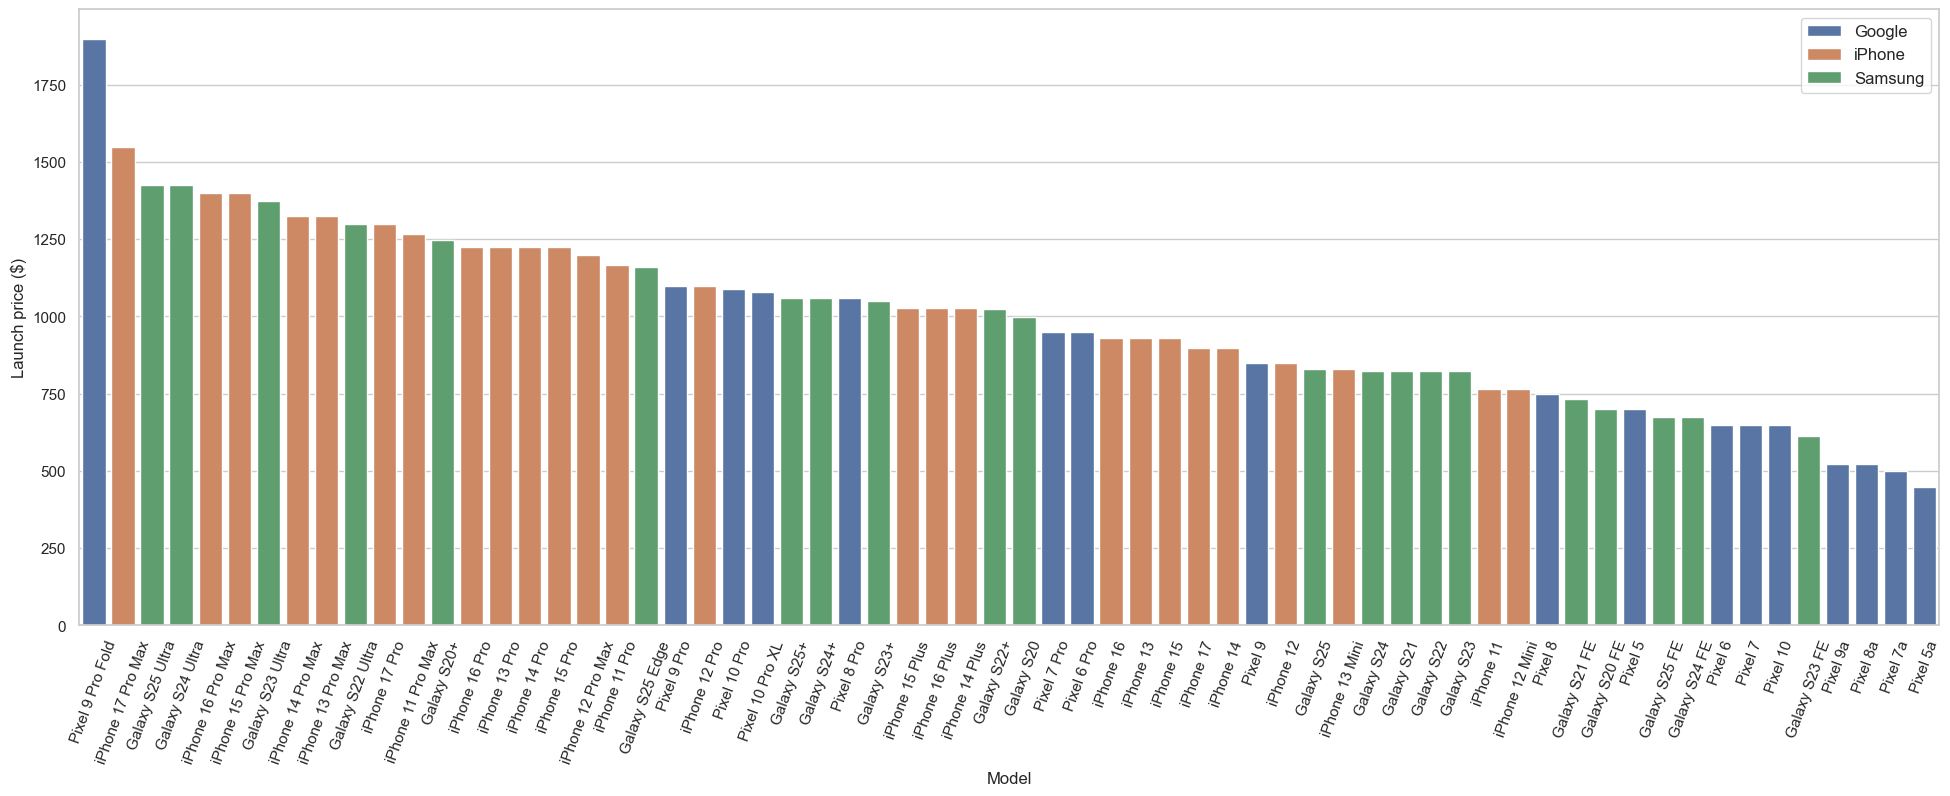

In [4]:
launch_ref['brand'] = launch_ref['submodel_name'].str.split().str[0]
launch_ref['brand'] = launch_ref['brand'].replace(['Pixel', 'Galaxy'], ['Google', 'Samsung'])
launch_ref = launch_ref.sort_values(by = 'official_launch_price', ascending = False)


plt.subplots(figsize = (24, 8))
launch_price_chart = sns.barplot(
    data = launch_ref,
    x = 'submodel_name',
    y = 'official_launch_price',
    hue = 'brand'
)

plt.legend(loc = 'upper right', fontsize = 12)
plt.xticks(rotation = 70)
plt.xlabel('Model')
plt.ylabel('Launch price ($)')
plt.show()

Poniżej porównanie oficjalnych cen premierowych dla wszystkich marek. Pierwszy wykres skupia się na modelach bazowych (np. iPhone 15, Samsung Galaxy S22, Google Pixel 6), drugi na flagowcach (iPhone Pro Max, Samsung Galaxy Ultra, Google Pixel Pro).

**Uwaga:** W linii Google pojawia się też Pro Fold/Fold XL (zajmuje pierwsze miejsce na powyższym wykresie), który zadebiutował w 2023 roku i jest obecnie najdroższą wersją Pixela. Najlepiej traktować go jednak jako alternatywę, a nie bezwzględny szczyt możliwości i flagowca. Jego cena 1799 USD odzwierciedla złożoność i elastyczny wyświetlacz, ale jednocześnie wypada gorzej pod kątem tradycyjnych cech flagowca. W skrócie: płaci się tu ogromną premię za składany tablet, ale jeśli ktoś szuka najlepszego aparatu i wydajności w ofercie Google, klasyczny Pixel Pro pozostaje prawdziwym flagowcem.

W przeciwieństwie do Google Fold, iPhone Pro Max i Samsung Galaxy Ultra to niepodważalne, absolutne flagowce w swoich markach z najlepszymi aparatami, maksymalną wydajnością i największymi bateriami.

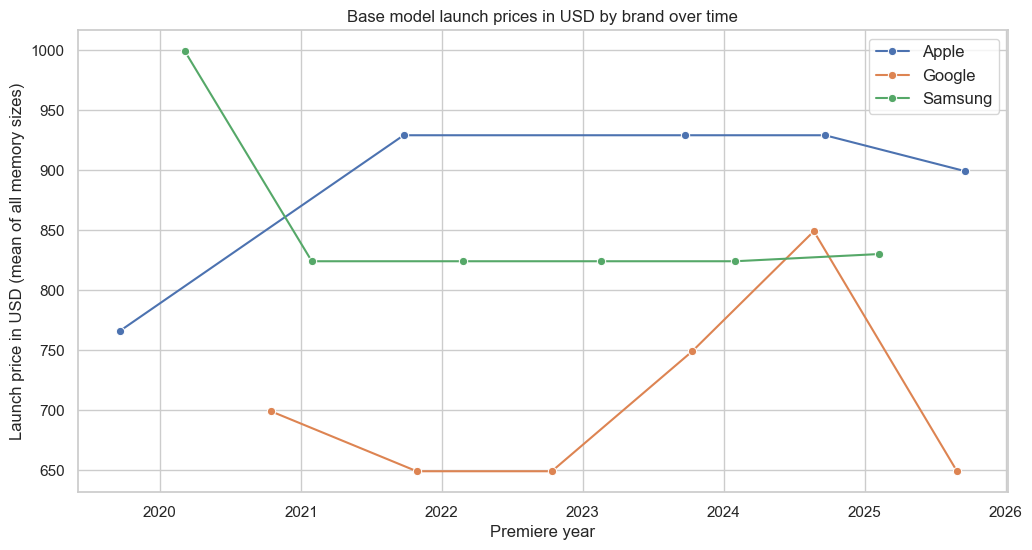

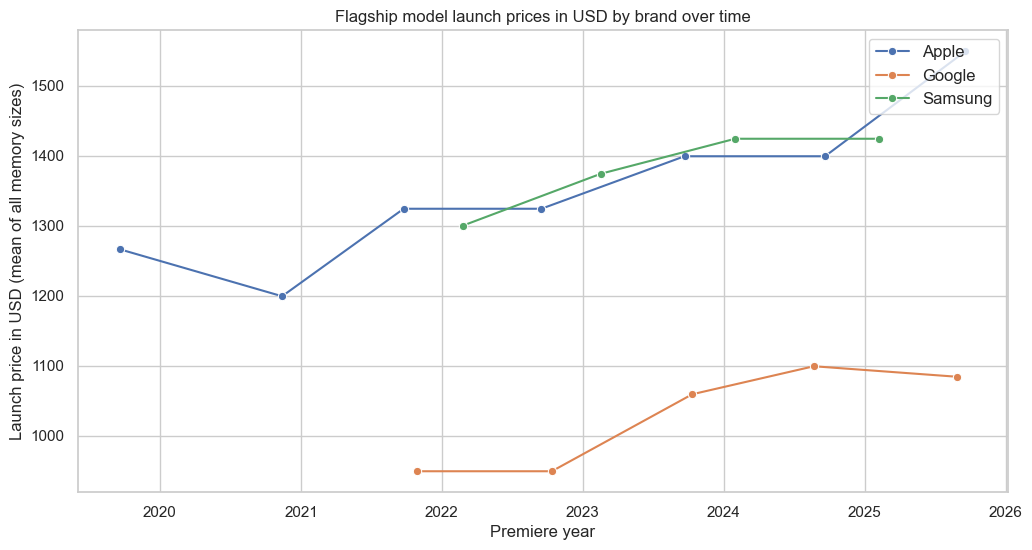

In [5]:

plt.subplots(figsize = (12, 6))
base_launch_chart = sns.lineplot(
    data = base_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Base model launch prices in USD by brand over time')
plt.show()


plt.subplots(figsize = (12, 6))
flagship_launch_chart = sns.lineplot(
    data = flagship_launch_ref,
    x = 'official_premiere_date',
    y = 'official_launch_price',
    hue = 'brand',
    marker = 'o'
)
plt.legend(loc = 'upper right', fontsize = 12)
plt.xlabel('Premiere year')
plt.ylabel('Launch price in USD (mean of all memory sizes)')
plt.title('Flagship model launch prices in USD by brand over time')
plt.show()

Google konsekwentnie pozycjonuje się jako najbardziej budżetowa marka. W obu tierach, bazowym i flagowym, smartfony Google są średnio około 20% tańsze od konkurencji.

Samsung i Apple bezpośrednio rywalizują na szczycie rynku. Modele bazowe Apple są zazwyczaj o około 10% droższe niż bazowe Samsungi, ale ta różnica znika na poziomie premium - modele Ultra Samsunga są wyceniane niemal identycznie jak warianty Pro Max Apple'a.

**Modele bazowe wszystkich marek łącznie**

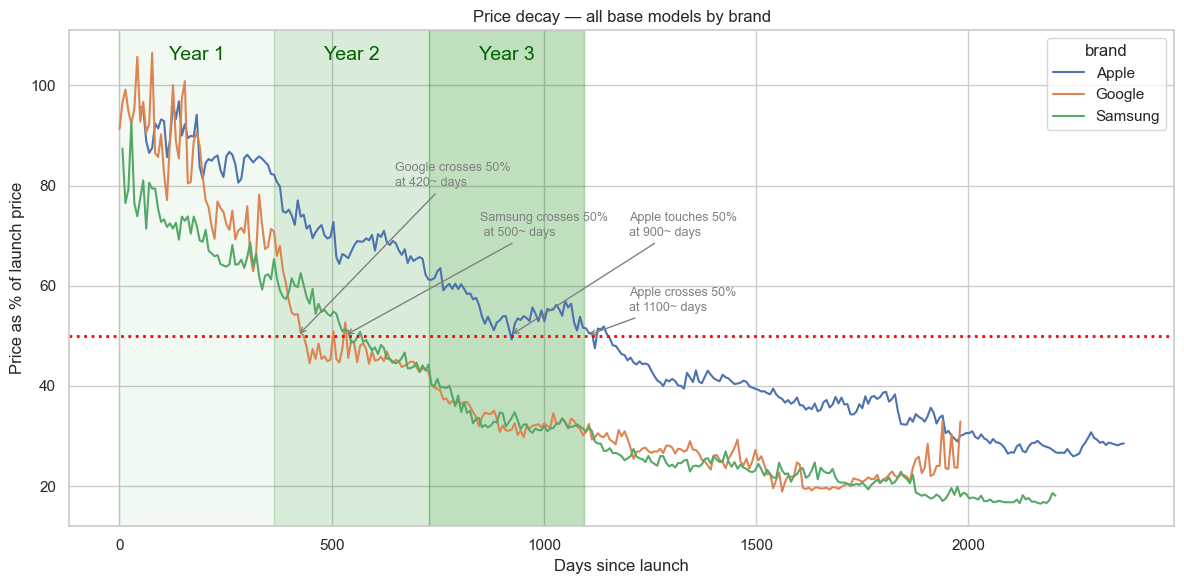

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1d = sns.lineplot(data=all_brands_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='brand', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay — all base models by brand')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()


plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')


plt.annotate(
    'Samsung crosses 50%\n at 500~ days',
    xy=(530, 50),
    xytext=(850, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.annotate(
    'Apple touches 50%\nat 900~ days',
    xy=(920, 50),
    xytext=(1200, 70),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.annotate(
    'Apple crosses 50%\nat 1100~ days',
    xy=(1100, 50),
    xytext=(1200, 55),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

plt.annotate(
    'Google crosses 50%\nat 420~ days',
    xy=(420, 50),
    xytext=(650, 80),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)
plt.show()


Zacieniony obszar zaznacza pierwsze trzy lata od premiery.

iPhone'y jako ostatnie przekraczają granicę 50%, dopiero około 900 dni po premierze, a wyraźnie ją przebijają przy mniej więcej 1100 dniach. Samsung osiąga ten poziom po około 500 dniach, Google po około 420 dniach. Apple ma też najwyższe ceny minimalne, stabilizuje się na poziomie 26–28% ceny premierowej po około 2000 dniach. Samsung spada do 16–17%, Google do około 20%.

**Modele bazowe iPhone'ów według generacji**

iPhone'y na Amazon są sprzedawane wyłącznie jako Renewed lub Renewed Premium. Linie ciągłe to standardowa klasa Renewed, linie przerywane to Renewed Premium. iPhone 17 jest wykluczony ze względu na zbyt krótką historię cenową.

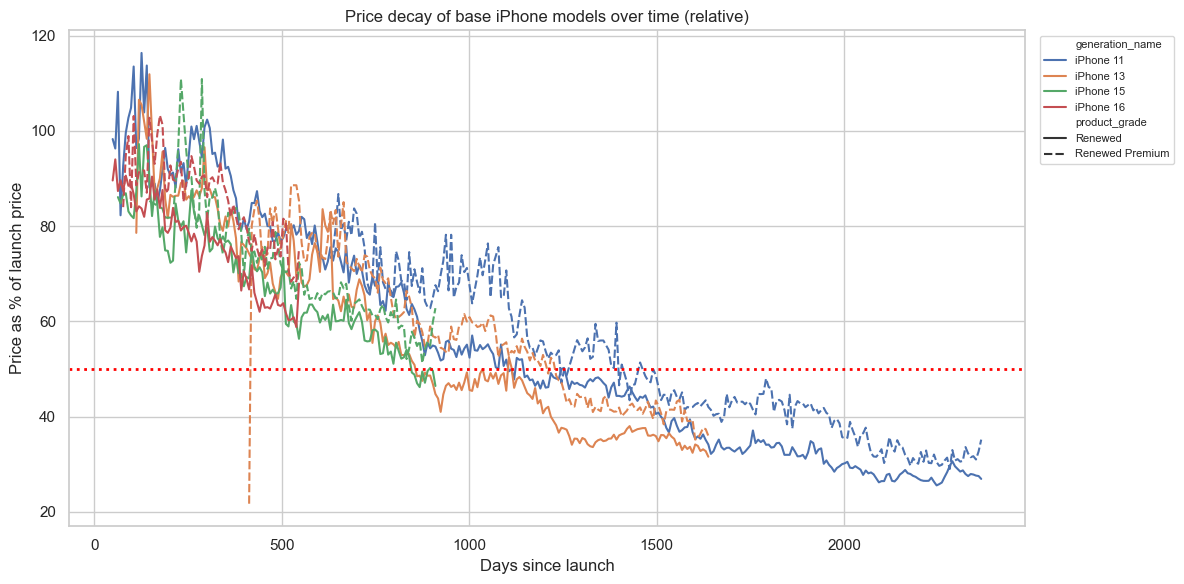

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1 = sns.lineplot(data=base_apple_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', style='product_grade', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base iPhone models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Wersja Renewed Premium konsekwentnie utrzymuje się powyżej krzywej standardowego Renewed dla tej samej generacji. Różnica pojawia się wcześnie i w miarę stabilnie utrzymuje się przez całą historię ceny, co sugeruje, że kupujący płacą premię za lepszy stan produktu niezależnie od tego, jak stary jest telefon. Różnica waha się w zależności od generacji, ale średnio wynosi około 10,2 punktu procentowego.

**Modele bazowe Samsunga według generacji**

Uwaga: rozróżnienie według product_grade nie miało tu sensu — poza jednym wyjątkiem mieliśmy praktycznie same wersje Renewed.

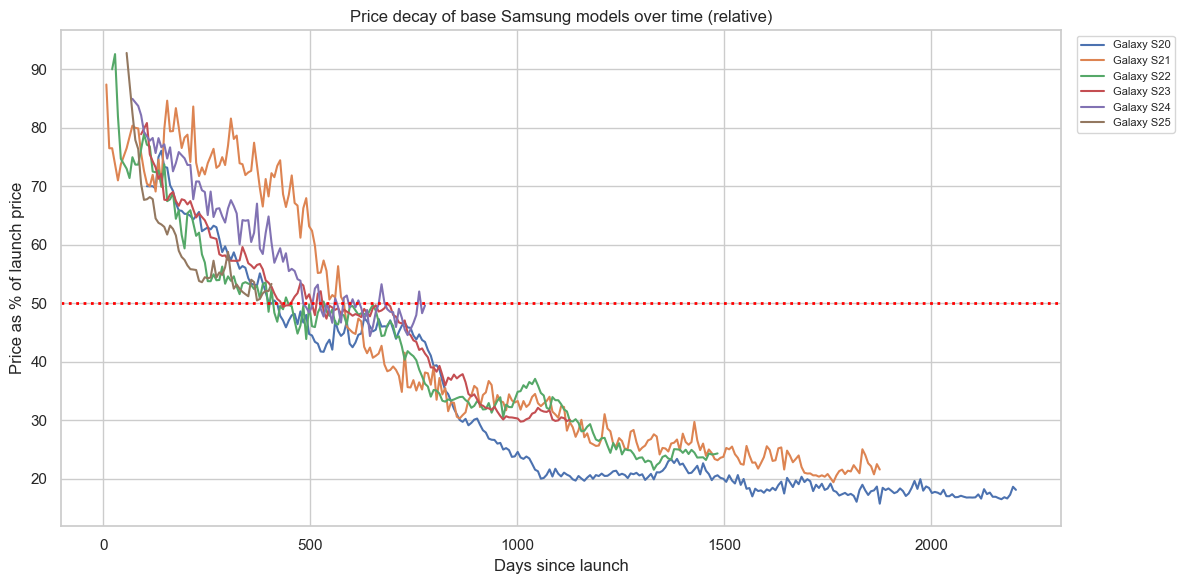

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1b = sns.lineplot(data=base_samsung_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Samsung models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Większość modeli bazowych Samsunga przekracza granicę 50% między 400 a 600 dniem od premiery, co jest zgodne z ogólnym trendem marki widocznym na wykresie zbiorczym. Galaxy S21 FE i S22 wyróżniają się najlepszą retencją wartości w pierwszym roku, choć w dłuższej perspektywie różnice między generacjami zacierają się.

**Modele bazowe Google Pixel według generacji**

Uwaga: podobnie jak w przypadku Samsunga, rozróżnienie według product_grade nie miało tu sensu.

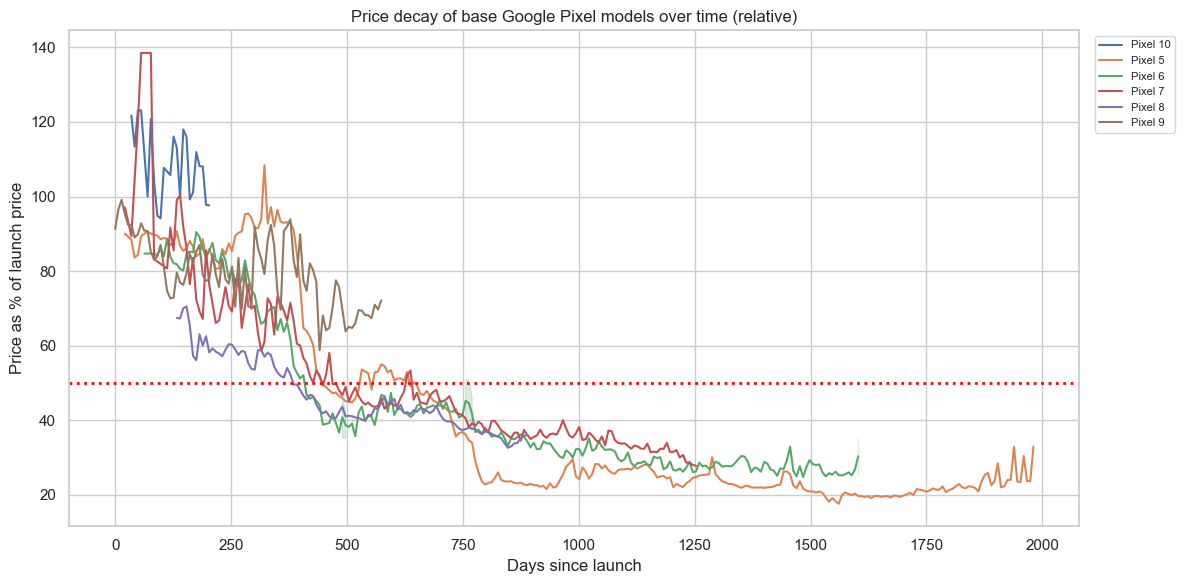

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_1c = sns.lineplot(data=base_google_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='generation_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of base Google Pixel models over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


Google Pixel 5 wyraźnie odbiega od reszty i utrzymuje wartość na poziomie zbliżonym do iPhone'ów w pierwszym roku, co jest anomalią w tej grupie. Pozostałe modele bazowe zachowują się podobnie do siebie, z wyraźniejszymi różnicami dopiero po przekroczeniu granicy 500 dni od premiery.

**Submodele iPhone'a 13 - spadek cen w obrębie generacji**

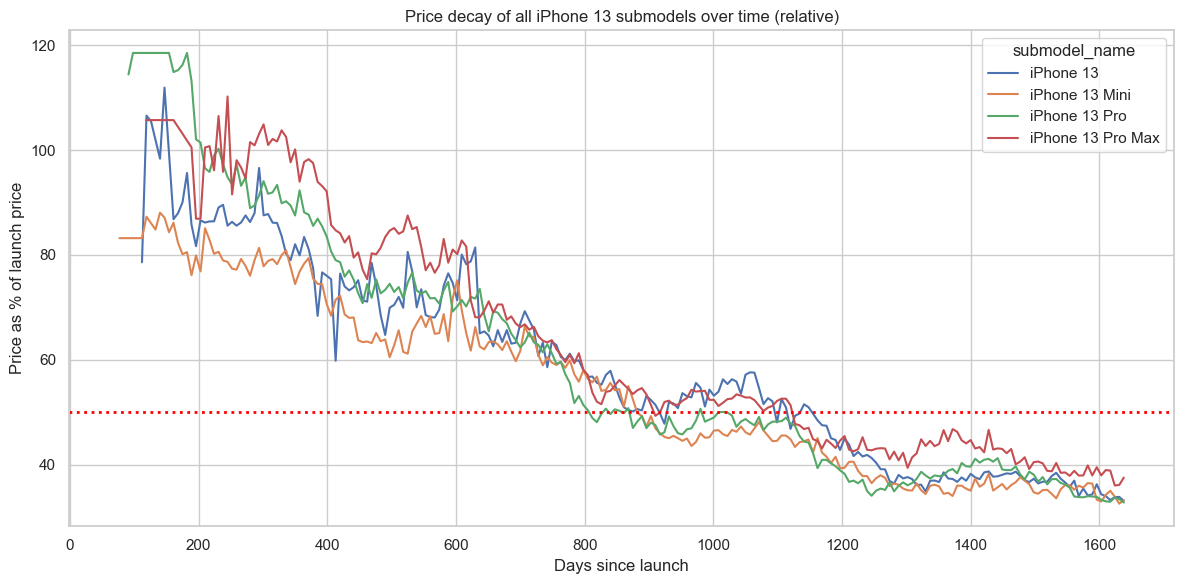

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
pd_chart_2 = sns.lineplot(data=iphone13_decay_df, x='days_rounded', y='price_pct_of_launch',
    hue='submodel_name', ax=ax)
ax.axhline(50, color='red', linestyle='dotted', linewidth=2)
ax.set_title('Price decay of all iPhone 13 submodels over time (relative)')
ax.set_xlabel('Days since launch')
ax.set_ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()

Pro Max zdaje się być submodelem z najlepszą retencją wartości na niemal każdym etapie historii ceny iPhone'a 13. Co ciekawe, zachowuje około 40% ceny premierowej nawet po 1600 dniach.

Na przeciwnym biegunie Mini traci wartość najszybciej, co prawdopodobnie odzwierciedla niższy popyt i mniejszą popularność tego submodelu na rynku wtórnym.

## Spadek cen według tierów

Skoro przyjrzeliśmy się już submodelom iPhone'a 13, czas na analogiczną analizę dla wszystkich tierów osobno dla każdej marki.

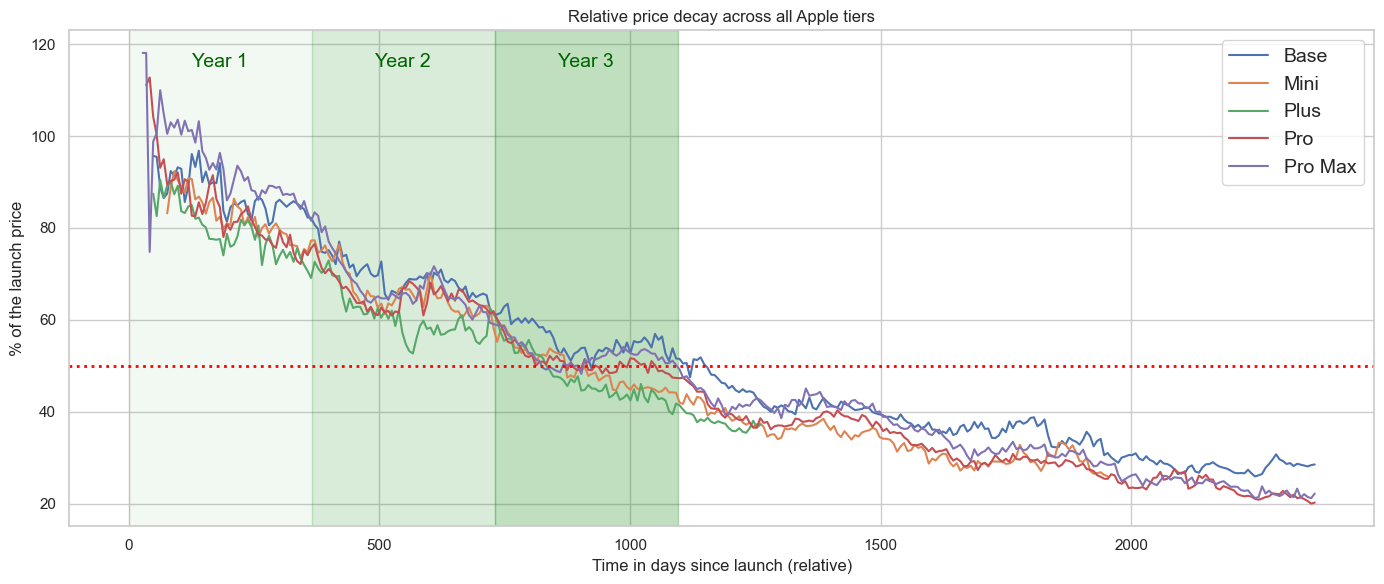

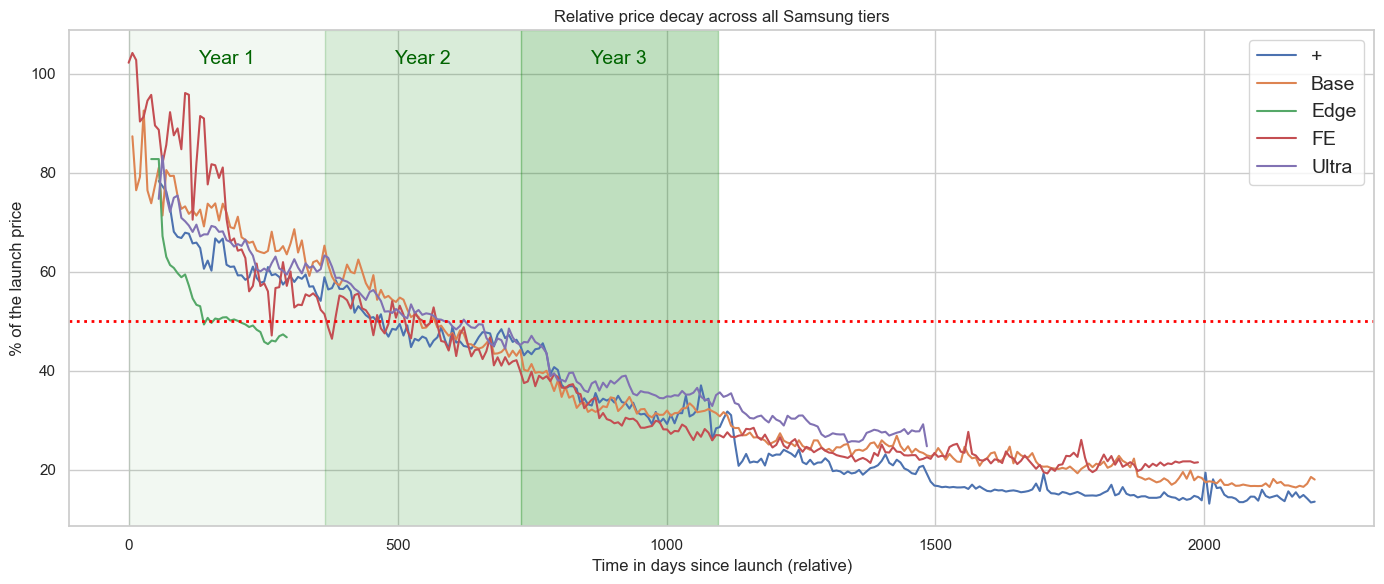

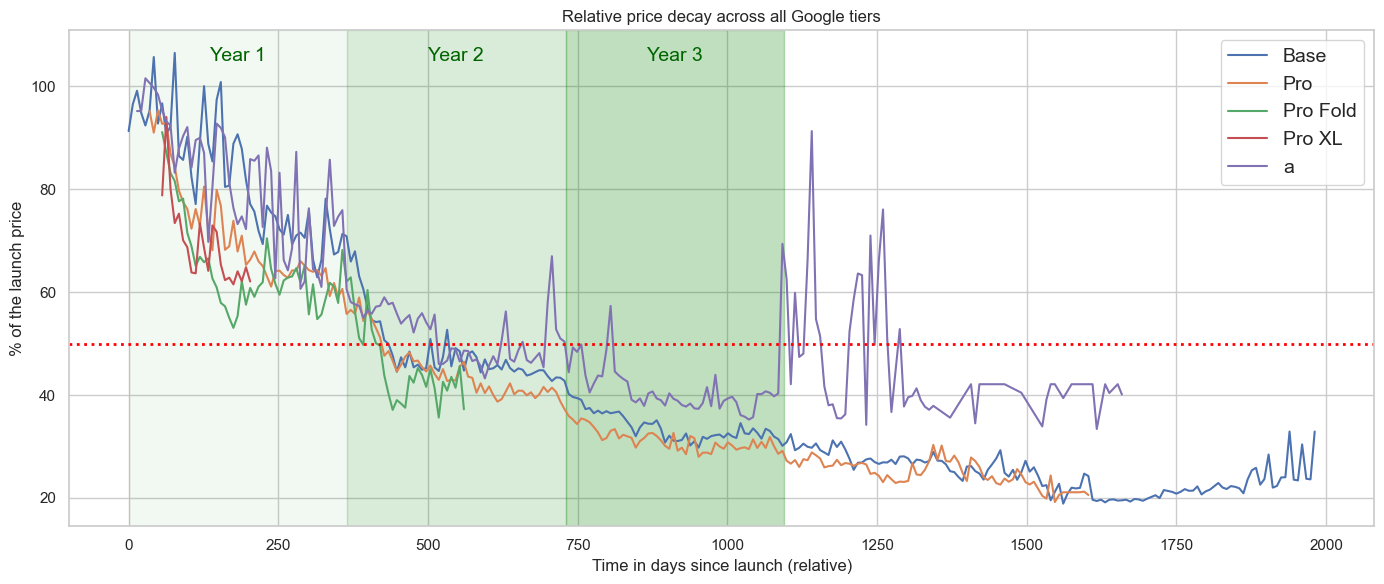

In [11]:

#Apple
plt.subplots(figsize = (14, 6))
pd_submodels_1a = sns.lineplot(
    apple_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Apple tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 115, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 115, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 115, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



#Samsung
plt.subplots(figsize = (14, 6))
pd_submodels_1b = sns.lineplot(
    samsung_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Samsung tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 102, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 102, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 102, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()


#Google
plt.subplots(figsize = (14, 6))
pd_submodels_1c = sns.lineplot(
    google_tier_price_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    hue = 'tier'
)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Relative price decay across all Google tiers')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('% of the launch price')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 105, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 105, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 105, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()

Wbrew temu, czego można by się spodziewać na podstawie iPhone'a 13, to standardowe modele bazowe Apple wykazują najwyższą stabilność cenową na przestrzeni generacji. Pro Max radzi sobie wyjątkowo dobrze w określonych przedziałach, ale w długim terminie to wersja bazowa konsekwentnie utrzymuje wyższy procent ceny premierowej.

Samsung wyraźnie przechodzi przez różne fazy retencji wartości. W pierwszym roku górują modele FE (Fan Edition) i nazowy. Około 500. dnia do gry wchodzi Ultra, który stopniowo przejmuje prowadzenie i utrzymuje je do końca dostępnych danych (około 1500 dni). Warianty Edge tracą wartość wyjątkowo agresywnie.

Lineup Google'a pokazuje najbardziej skrajną polaryzację tierów. Seria budżetowa Pixel 'a' wyraźnie prowadzi, choć przy dużej zmienności utrzymuje wartość lepiej niż modele Base i Pro. Na przeciwnym biegunie jest submodel Pro Fold, wspomniany już w sekcji cen premierowych jako najdroższy smartfon w całym zbiorze, choć niewybrany jako flagowiec. W jego przypadku obserwujemy jeden z najgwałtowniejszych spadków cen w całym datasecie.

## Spadek cen w dolarach

Analiza procentowych spadków jest ważna, ale równie istotne jest spojrzenie na surowe wartości w USD. Daje to konkretny, realny punkt odniesienia ile dany telefon faktycznie kosztuje w różnych momentach historii ceny.

Poniżej wykresy spadku cen w USD. Najpierw średnie dla wszystkich marek i tierów łącznie, a następnie zestawienie tierów bazowych i flagowych dla każdej marki (wykres Google zawiera też Pro Fold jako ciekawy przykład). Są to średnie liczone na bazie wszystkich generacji i wielkości pamięci, więc rzeczywiste ceny konkretnych modeli będą się różnić.

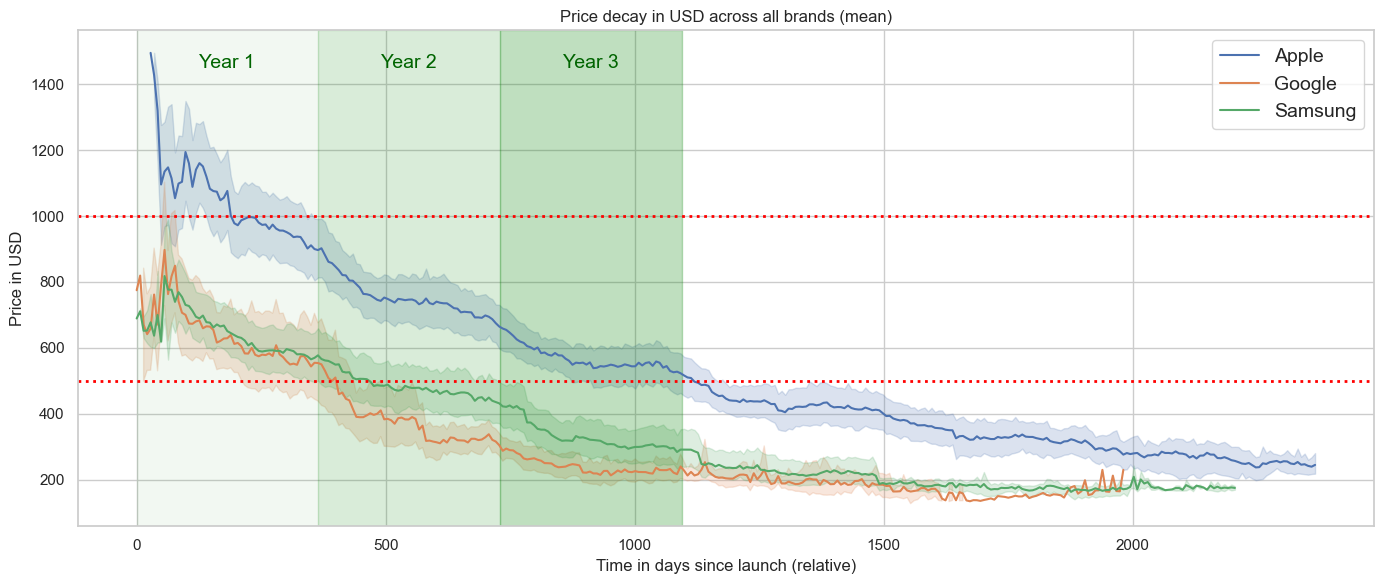

In [12]:

plt.subplots(figsize = (14, 6))
pd_dollar_chart1 = sns.lineplot(
    data = dollar_all_brands_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'brand'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across all brands (mean)')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1450, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1450, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1450, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()


Smartfony Apple utrzymują stałą premię cenową rzędu 200-400 USD nad konkurencją przez cały cykl. W pewnych momentach niektóre iPhone'y są nawet o 100% droższe od bezpośredniej konkurencji. Ostatecznie średnia cena minimalna iPhone'a stabilizuje się w okolicach 200-300 USD.

Google i Samsung startują na podobnym poziomie, około 700–800 USD. Po pierwszym roku Samsung trzyma wartość nieco lepiej, utrzymując stabilną premię około 100 USD nad Google przez resztę cyklu. Samsung osiąga stabilny dołek cenowy blisko 200 USD około 1500 dni od premiery, Google spada nieco niżej do poziomu 150–180 USD w tym samym czasie.

Warto pamiętać, że to średnie, które pokazują ogólne trendy, a nie dokładne ceny. Poniżej rozbicie na tiery dla każdej marki.

----------------------------------------------------

#### Porównanie tierów według marki

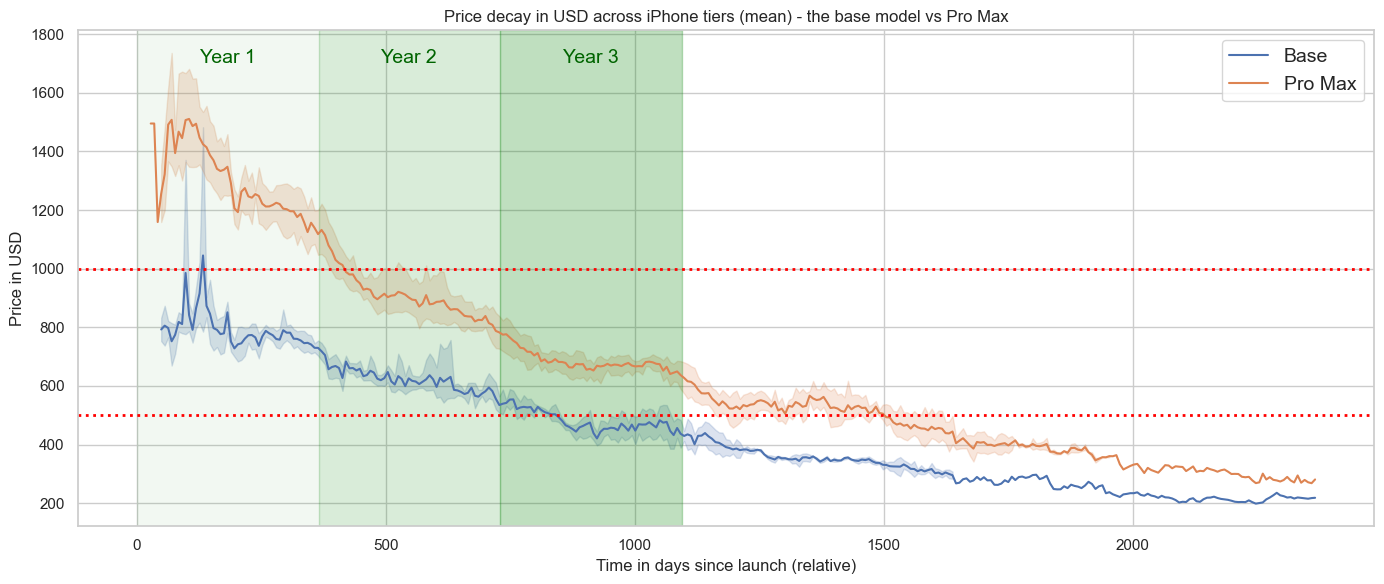

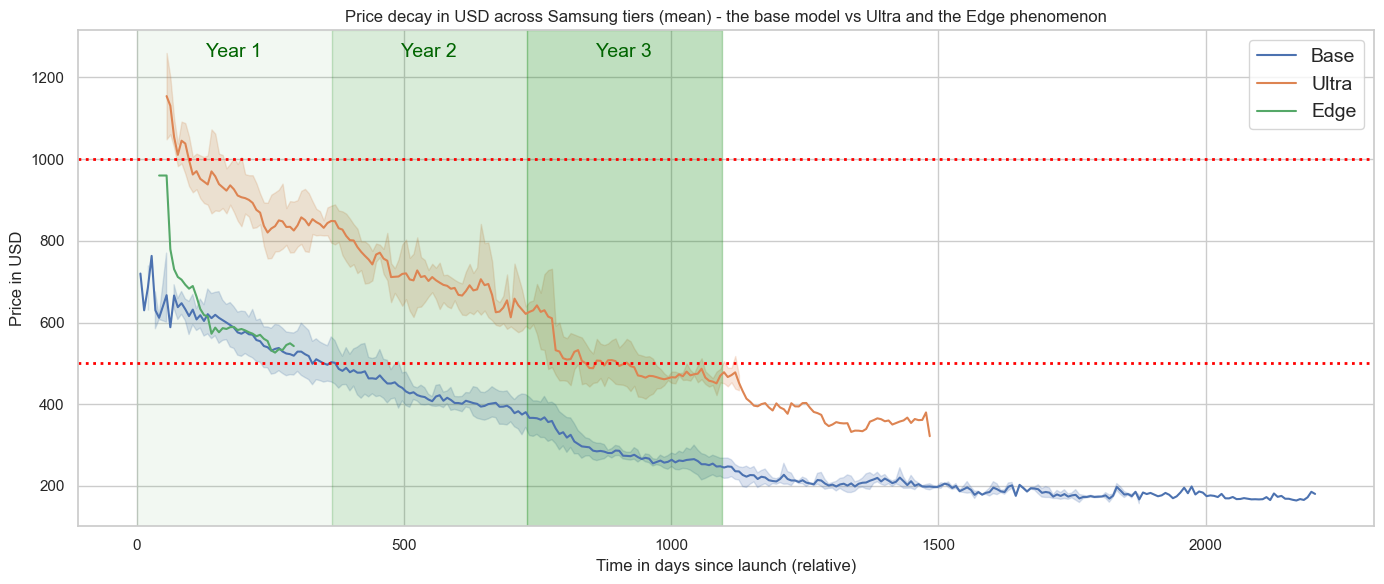

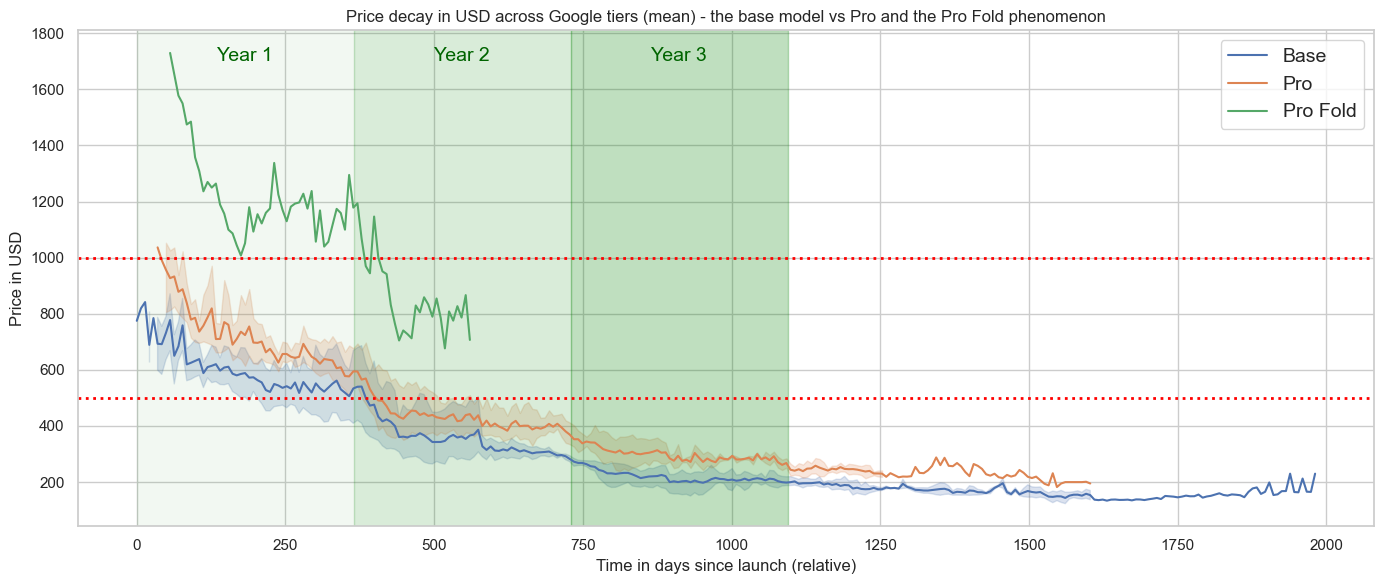

In [13]:
plt.subplots(figsize = (14, 6))
pd_dollar_chart1a = sns.lineplot(
    data = apple_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across iPhone tiers (mean) - the base model vs Pro Max')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



plt.subplots(figsize = (14, 6))
pd_dollar_chart1b = sns.lineplot(
    data = samsung_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across Samsung tiers (mean) - the base model vs Ultra and the Edge phenomenon')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1250, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1250, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1250, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



plt.subplots(figsize = (14, 6))
pd_dollar_chart1c = sns.lineplot(
    data = google_dollar_price_decay_df,
    x = 'days_rounded',
    y = 'NEW',
    hue = 'tier'
)
plt.axhline(1000, color='red', linestyle='dotted', linewidth=2)
plt.axhline(500, color='red', linestyle='dotted', linewidth=2)
plt.title('Price decay in USD across Google tiers (mean) - the base model vs Pro and the Pro Fold phenomenon')
plt.xlabel('Time in days since launch (relative)')
plt.ylabel('Price in USD')
plt.legend(loc = 'upper right', fontsize = 14)
plt.tight_layout()

plt.axvspan(0, 365, alpha=0.05, color='green')
plt.axvspan(365, 730, alpha=0.15, color='green')
plt.axvspan(730, 1095, alpha=0.25, color='green')
plt.text(182, 1700, 'Year 1', fontsize=14, color='darkgreen', ha='center')
plt.text(547, 1700, 'Year 2', fontsize=14, color='darkgreen', ha='center')
plt.text(912, 1700, 'Year 3', fontsize=14, color='darkgreen', ha='center')

plt.show()



## Apple - wyraźna premia i silna retencja
Na premierze Pro Max jest droższa od modelu bazowego nawet o ponad 600 USD (około 75% więcej). Jednak ta różnica szybko się kurczy. W pierwszym roku Pro Max traci około 30% ceny premierowej, schodząc poniżej 1000 USD, podczas gdy Base traci tylko 20%. To redukuje pierwotną premię Pro Maxa mniej więcej o połowę, do poziomu około 300 USD.

Ta różnica 250-300 USD utrzymuje się stabilnie przez pierwsze trzy lata. Około 1600. dnia Pro Max kosztuje już 400 USD a bazowy model iPhone'a 300 USD. Po 2000 dniach Pro Max stabilizuje się na poziomie około 280 USD, a wersja Base spada do mniej więcej 200 USD.


## Samsung - ciekawy przykład submodelu Edge i dobra retencja Ultra

W ekosystemie Samsunga wyróżnia się model Edge z wyjątkowo gwałtowną utratą ceny. Startując przy około 950 USD - gdzieś pomiędzy Base i flagowcem, gwałtownie spada do poziomu Base (600 USD) w zaledwie 150-80 dni. Tak szybkie tąpnięcie może być efekt ryzyka hardware'owego i kosztów naprawy, ale aby to rzetelnie zbadać, potrzebowalibyśmy więcej danych i opinii konsumentów.

Tymczasem modele Ultra wchodzą na rynek wtórny przy około 1150 USD, z premią 400–500 USD nad Base. Ultra schodzi poniżej 1000 USD w ciągu kilku miesięcy, stabilizując się na poziomie 800–850 USD po roku. Co ciekawe, jego premia spada wolniej niż porównywalne iPhone'y, utrzymując stabilną różnicę 200–300 USD. Przy 1400 dniach Ultra trzyma się mocno na poziomie 350 USD. Wersja bazowa Samsunga osiąga stabilny dołek cenowy przy 150–180 USD, wypadając tylko nieznacznie gorzej niż bazowy iPhone w długim terminie.

## Google - krach Pro Fold i małe różnice tierów

Mimo że Pro Fold wchodzi na rynek przy najwyższej cenie w całym zbiorze (1700 USD), to właśnie ten model doświadcza najbardziej gwałtownych spadków ceny. W ciągu 6 miesięcy spada do 1000 USD, a przy 500. dniu osiąga już poziom 700-800 USD, tracąc ponad 50% wartości w rekordowym czasie.

W odróżnieniu od Apple i Samsunga, modele Base i Pro Google'a są do siebie zaskakująco zbliżone. Początkowa premia to zaledwie 200–250 USD, ale ta różnica kurczy się do poziomu poniżej 100 USD już po pierwszym roku. Obydwa tiery doświadczają gwałtownego spadku w pierwszym roku: Base spada z 800 do 500 USD, Pro praktycznie go dogania krótko później.

Wariant bazowy stabilizuje się przy cenie 200 USD w roku drugim, schodzi do 150–180 USD w roku czwartym i wykazuje zaskakujący wzrost z powrotem do 200 USD około 2000 dni - ciężko powiedzieć, czym jest spowodowany. Pro zachowuje się podobnie, co sprawia, że różnica między nimi na końcu cyklu to zaledwie 20–40 USD.

---
# Porównanie marek rok po premierze

Zamiast analizować pełną krzywą deprecjacji, tu robimy migawkę około 365 dni od premiery i ustawiamy wszystkie generacje obok siebie. To czytelny sposób na odpowiedź, które telefony najlepiej utrzymują wartość w pierwszym roku.

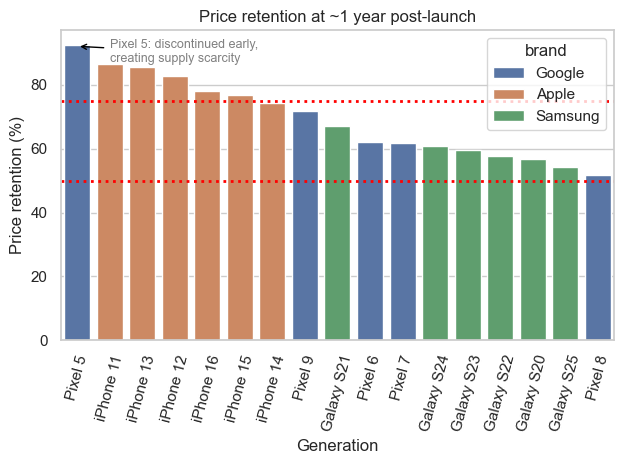

In [14]:
order = retention_1yr_df['generation_name'].tolist()

pd_chart_7 = sns.barplot(
    data=retention_1yr_df,
    x='generation_name',
    y='price_retention',
    hue='brand',
    order=order)

plt.axhline(75, color='red', linestyle='dotted', linewidth=2)
plt.axhline(50, color='red', linestyle='dotted', linewidth=2)
plt.title('Price retention at ~1 year post-launch')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation=75)
plt.tight_layout()

#Annotation
plt.annotate(
    text = 'Pixel 5: discontinued early,\ncreating supply scarcity',
    xy=(0, 92),
    xytext=(1, 87), color = 'gray',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.show()

iPhone'y dominują w górnej części wykresu. Pixel 5 wyraźnie odbiega od reszty telefonów Google. Prawdopodobnie wynika to z niskiej ceny premierowej (699 USD) i wcześniejszego wycofania przez Google, aczkolwiek to tylko spekulacje. W przypadku innych generacji Pixela widzimy wyraźną różnicę w rocznej retencji ceny

---
# Rozkład cen przez całą historię

Boxplot poniżej przedstawia pełny rozkład cen przez całą historię dla każdej marki: medianę, kwartyle i outliery. Daje to obraz tego, jak duże są wahania cen w obrębie każdej marki.

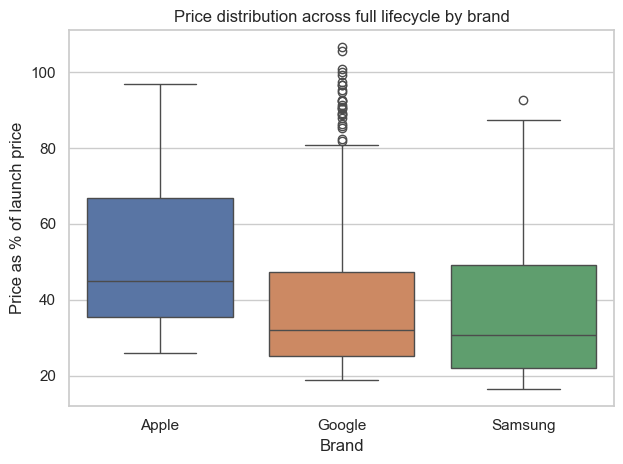

In [15]:
pd_chart_8 = sns.boxplot(
    data=all_brands_decay_df,
    x='brand',
    y='price_pct_of_launch',
    hue='brand')
plt.title('Price distribution across full lifecycle by brand')
plt.xlabel('Brand')
plt.ylabel('Price as % of launch price')
plt.tight_layout()
plt.show()

Apple wyraźnie wiedzie prym pod względem mediany, a IQR marki jest przesunięty wyżej niż u konkurencji. Google i Samsung mają bardzo podobne rozkłady z drobnymi różnicami. Marka Google ma też najwyższą liczbę outlierów ze wszystkich trzech marek.

---
# Analiza sprzedaży

Pole monthly_sold w API Keepa reprezentuje dolną granicę przedziału sprzedaży, a nie precyzyjną liczbę sprzedanych sztuk. Wartość 50 oznacza, że faktyczna sprzedaż mogła wynieść od 50 do 99 egzemplarzy.

Z tego powodu precyzyjne mierzenie wolumenów nie jest możliwe. Jako rozwiązanie wybrałem ostatni odczyt każdego miesiąca dla każdego ASIN-u i zsumowałem wyniki, co powinno dawać możliwie jak najbardziej wiarygodny wskaźnik względnej aktywności rynkowej.

Keepa śledzi te dane konsekwentnie dopiero od końca 2023 roku, więc mamy około 2 lat danych. Rozważałem, czy włączyć te dane do analizy, ale obecny format pozwala na zaobserwowanie pewnych tendencji i powinien wystarczyć do zauważenia pewnych wzorców i porównania ze sobą marek, tierów i wybranych submodeli.

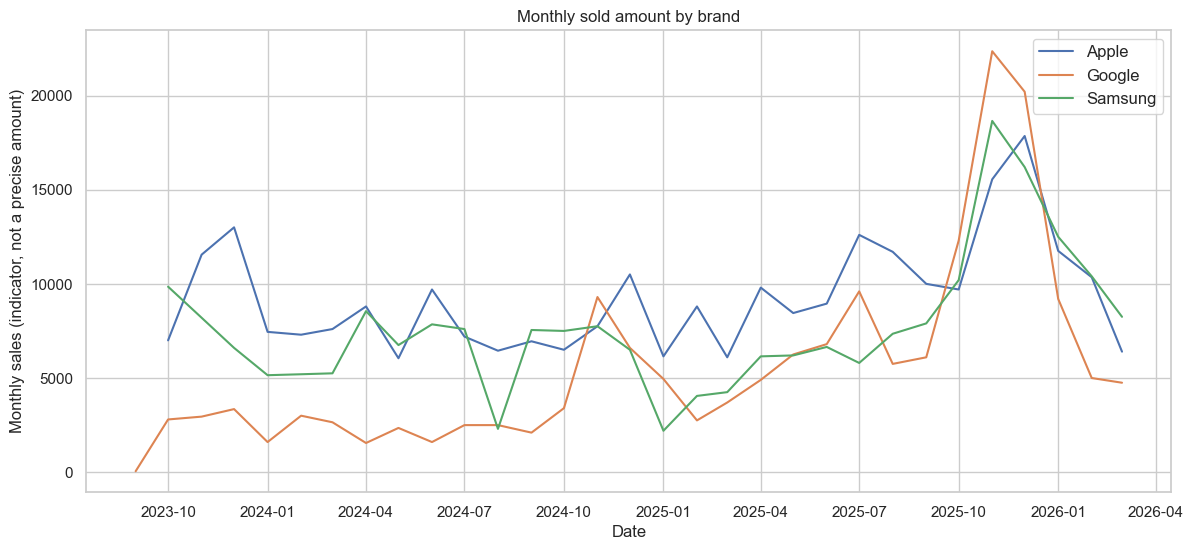

In [16]:
plt.subplots(figsize = (14, 6))
all_brands_ms_chart = sns.lineplot(
    data = brand_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'brand'
)
plt.title('Monthly sold amount by brand')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()


Wszystkie powyższe wartości to wyłącznie wskaźniki, nie należy ich traktować jako precyzyjnych liczb.

Apple prowadzi jako najpopularniejsza marka, choć różnice nie są duże i marka często szła łeb w łeb z Samsungiem. Google zanotował pierwszy większy wzrost w Q4 2024, potem w lipcu 2025 i wreszcie w Q4 2024, co sugeruje, że mogą być to okresy wzmożonego zainteresowania. Ciekawostką jest pojawienie się Google na szczycie sprzedaży w listopadzie-grudniu 2025.

Wszystkie trzy marki notują wyraźny skok w Q4 2025, a Google i Apple również w lipcu 2025.

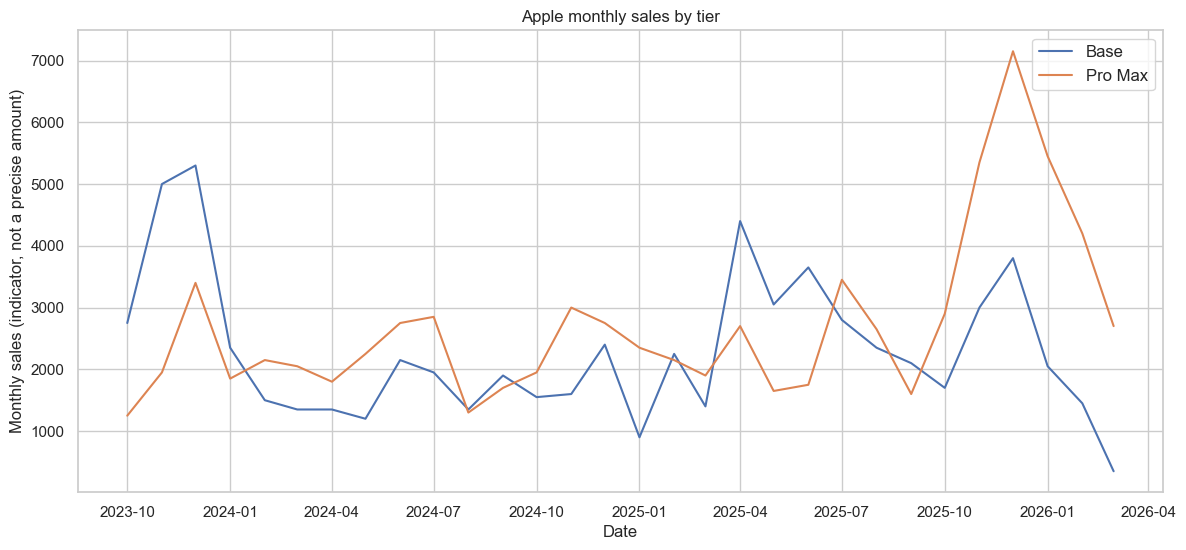

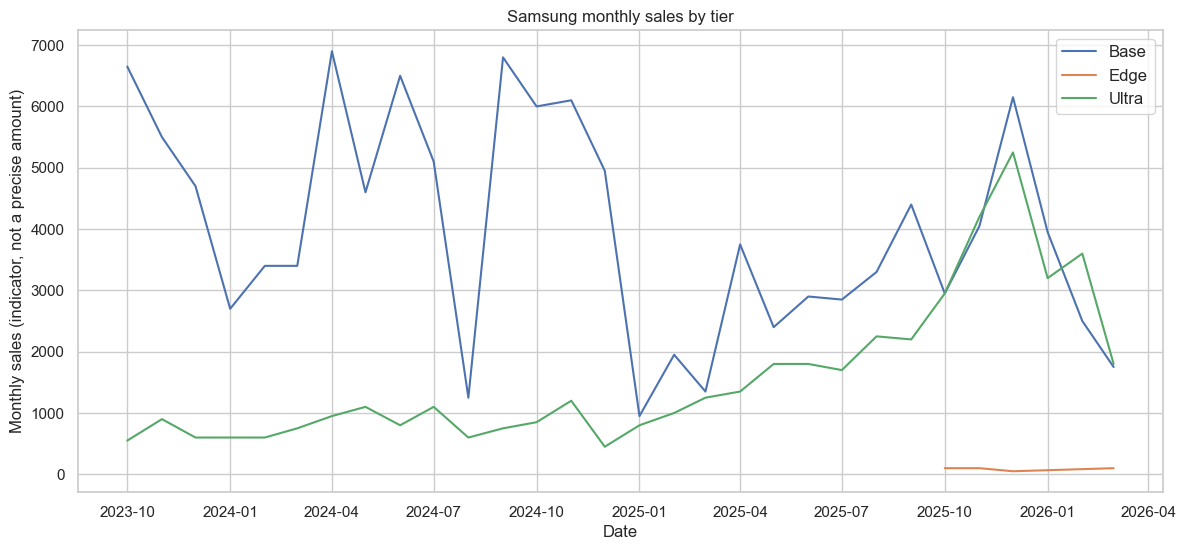

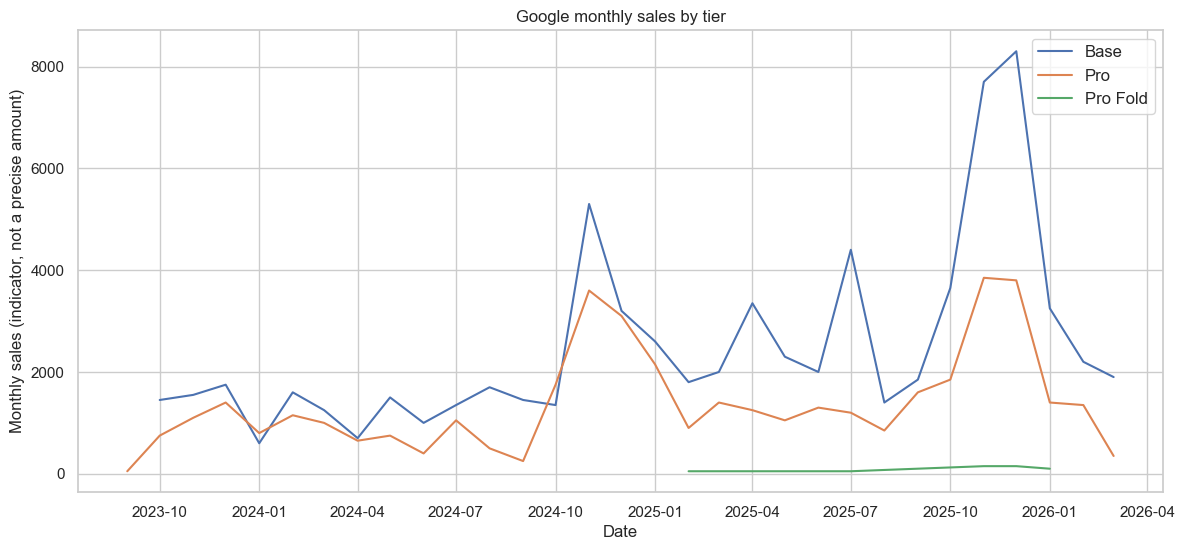

In [17]:
plt.subplots(figsize = (14, 6))
apple_tiers_ms_chart = sns.lineplot(
    data = apple_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Apple monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()


plt.subplots(figsize = (14, 6))
samsung_tiers_ms_chart = sns.lineplot(
    data = samsung_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Samsung monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()



plt.subplots(figsize = (14, 6))
google_tiers_ms_chart = sns.lineplot(
    data = google_ms_df,
    x = 'month_year',
    y = 'monthly_sold',
    hue = 'tier'
)
plt.title('Google monthly sales by tier')
plt.ylabel('Monthly sales (indicator, not a precise amount)')
plt.xlabel('Date')
plt.legend(loc = 'upper right', fontsize = 12)
plt.show()

Tiery Base i Pro Max Apple'a zamieniają się w pozycji lidera przez cały okres obserwacji. Do wyciągnięcia twardych wniosków w tym kontekście potrzebne byłoby dłuższe okno danych.

Tier bazowy Samsunga prowadzi pod względem wolumenu przez większość okresu, choć Ultra notuje wyraźny skok w Q4 2025. Wariant Edge, o którym wspominałem wcześniej, potwierdza słabe zainteresowanie również w tym zbiorze danych.

Modele Base i Pro Google'a idą bardzo blisko siebie przez większość czasu, co pasuje także do dość małej różnicy w spadku ich cen. Wersja bazowa notuje gwałtowny wzrost w Q4 2025. Pro Fold, mimo że jest najdroższym smartfonem w całym zbiorze, notuje konsekwentnie niski wolumen sprzedaży, co tylko potwierdza wnioski płynące z analizy cenowej. Nie jest to pożądana wersja smartfona.

**Sprzedaż bazowych iPhone'ów i analiza istotnych dat**

Szare przerywane linie oznaczają okno premiery iPhone'a (wrzesień), pomarańczowe - Black Friday, czerwone - Boże Narodzenie, fioletowe - Prime Day. Dane zaczynają się od końca 2023, więc widoczne są tylko dwa pełne cykle.

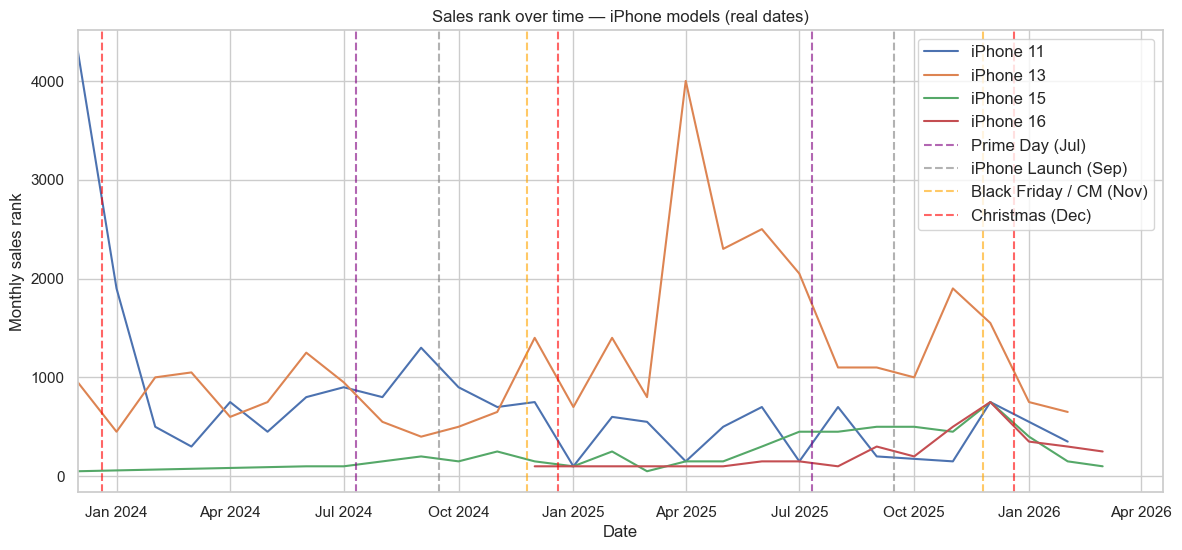

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_5 = sns.lineplot(data=apple_base_ms_df, x='month_year', y='monthly_sold',
    hue='generation_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, loc='upper right', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales rank over time — iPhone models (real dates)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales rank')
ax.set_xlim(left=pd.Timestamp('2023-12-01'))
plt.show()

## iPhone 13 - król rynku wtórnego
Starsze modele zdecydowanie dominują na początku obserwacji — iPhone 11 i 13 idą łeb w łeb przez cały rok 2024. Jednak w 2025 następuje wyraźny przełom: sprzedaż iPhone'a 11 znacznie spada, zrównując się z nowszymi modelami 15 i 16, a iPhone 13 notuje gwałtowny wzrost, co plasuje go jako niekwestionowanego lidera rynku odnowionych iPhone'ów.

---

Nowsze modele wolniej startują na rynku wtórnym.
- Sprzedaż iPhone'a 15 pozostaje relatywnie mała w pierwszym roku i nieznacznie rośnie po premierze 16. Pierwszy wyraźny punkt zwrotny to lipiec 2025 (być może to efekt Prime Day), który zapoczątkowuje trend wzrostowy utrzymujący się do końca Q4 2025.
- iPhone 16 zachowuje się podobnie, co poprzednia generacja, ale kończy pierwszy rok dużo mocniej niż iPhone 15. Sprzedaż zaczyna rosnąć tuż po premierze iPhone'a 17 i utrzymuje wyraźny trend wzrostowy przez ostatni kwartał 2025.

Dane zdają się potwierdzać, że sprzedaż smartfonów naturalnie wzrasta w ostatnim kwartale, a duże wydarzenia zakupowe jak Prime Day dają pewien impuls nowszym generacjom. Co więcej, premiera nowej generacji iPhone'a wydaje się działać jako katalizator wzrostu sprzedaży bezpośrednich poprzedników.

Wszystkie te wzorce warto jednak traktować z rezerwą, bo mamy tu tylko 2 lata danych!

**Sprzedaż w obrębie generacji - submodele iPhone'ów 11, 13 i 15**

W tym miejscu naturalnie nasuwa się pytanie o to, jak sprzedają się poszczególne submodele.

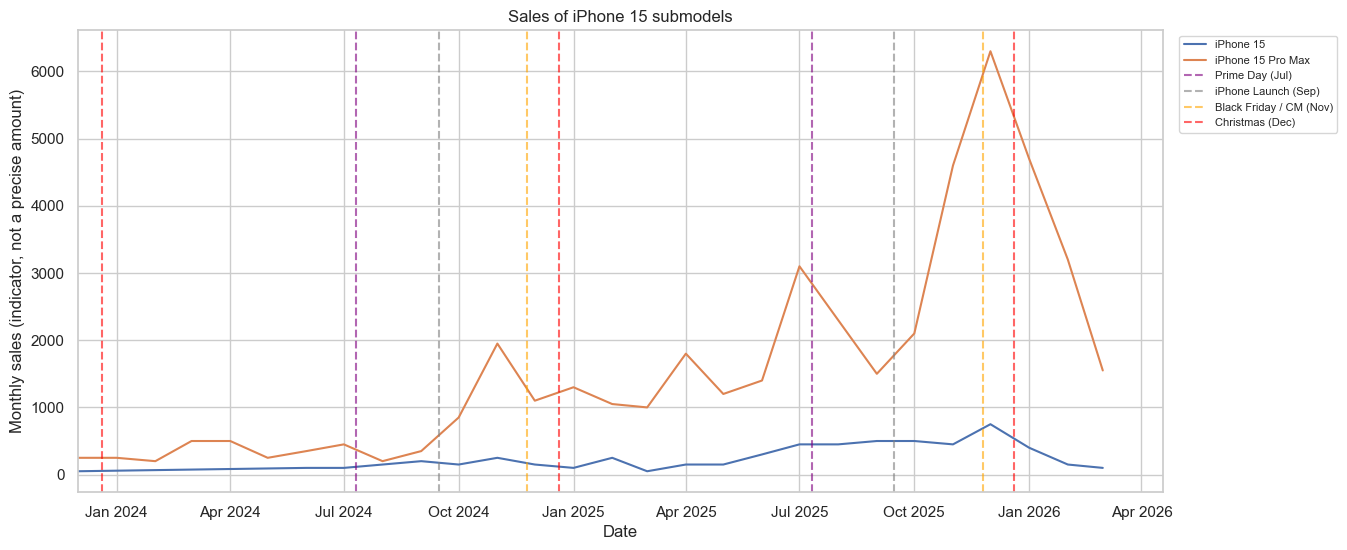

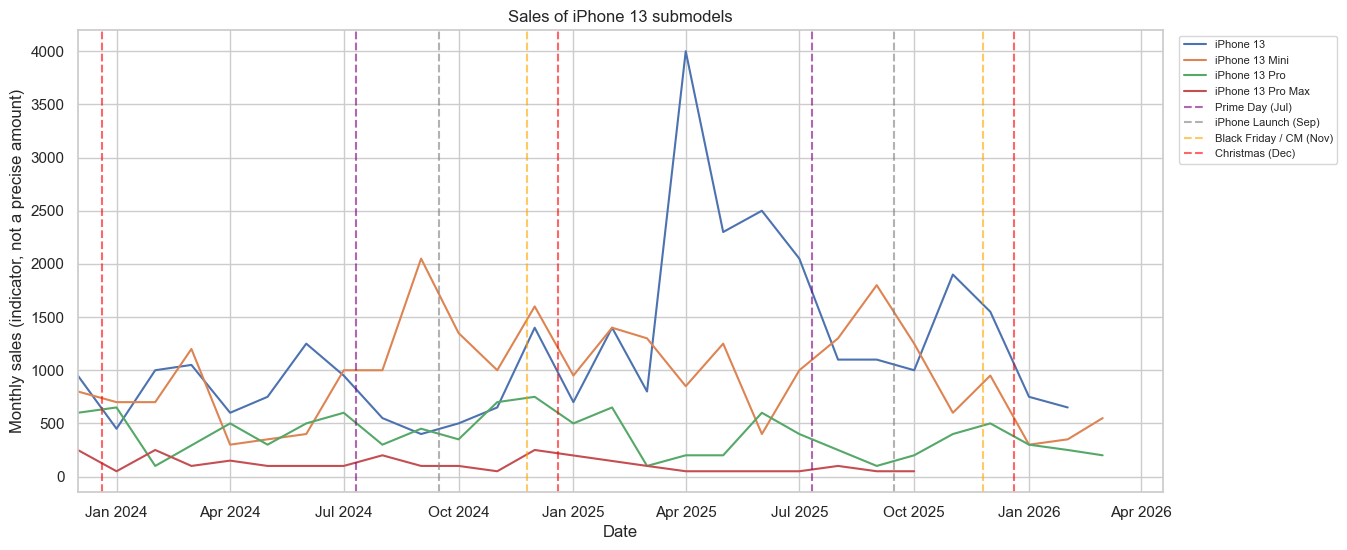

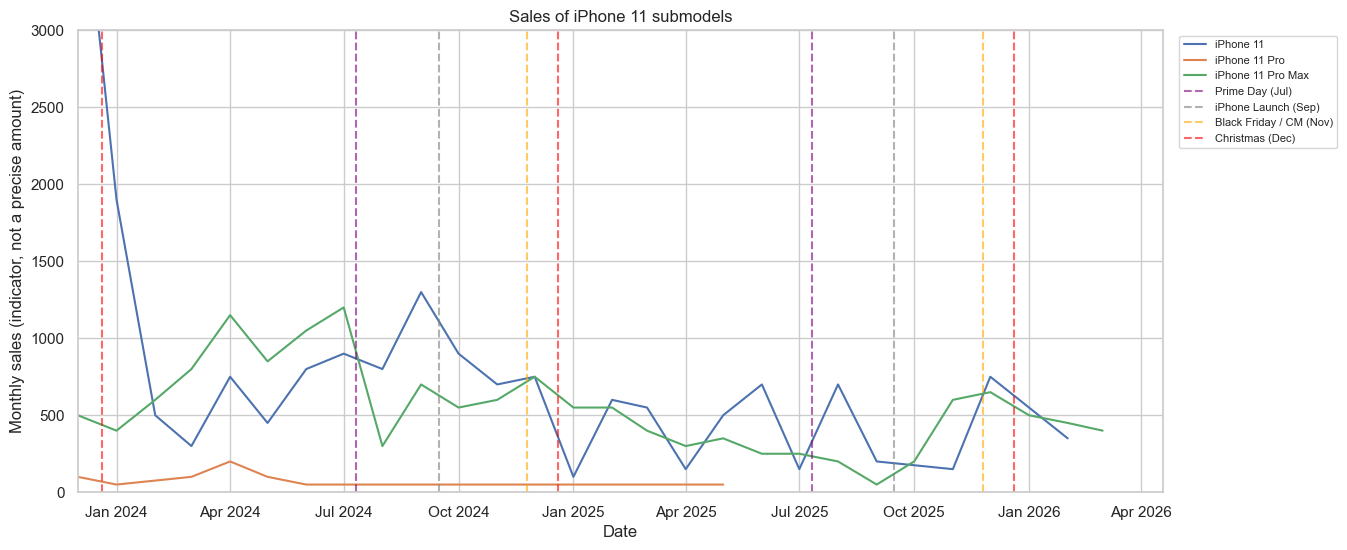

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone15_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 15 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()


fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_6 = sns.lineplot(data=iphone13_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 13 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
plt.show()


fig, ax = plt.subplots(figsize=(14, 6))
ms_chart_7 = sns.lineplot(data=iphone11_ms_df, x='month_year', y='monthly_sold',
    hue='submodel_name', ax=ax)

ax.axvline(pd.Timestamp('2023-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6, label='Prime Day (Jul)')
ax.axvline(pd.Timestamp('2023-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='iPhone Launch (Sep)')
ax.axvline(pd.Timestamp('2023-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6, label='Black Friday / CM (Nov)')
ax.axvline(pd.Timestamp('2023-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Christmas (Dec)')
for year in range(2024, 2026):
    ax.axvline(pd.Timestamp(f'{year}-07-11'), color='purple', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-09-15'), color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-11-25'), color='orange', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-12-20'), color='red', linestyle='--', linewidth=1.5, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title('Sales of iPhone 11 submodels')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly sales (indicator, not a precise amount)')
ax.set_xlim(left = pd.Timestamp('2023-12-01'))
ax.set_ylim(0, 3000)
plt.show()

## iPhone 15 - dominacja Pro Maxa
Wersja Pro Max wykazuje znaczną zmienność. Sprzedaż skacze bezpośrednio po premierze iPhone'a 16, a jeszcze mocniej po iPhone'a 17, osiągając szczyt pod koniec 2025. Ostatnio wzrost wyhamował, co może wiązać się z końcem sezonu zakupowego Q4 2025.

To zachowanie sugeruje, że kupujący często czekają z zakupem. Ponieważ Pro Max doświadcza najostrzejszego spadku ceny właśnie w tym pierwszym roku, czekanie pozwala kupić telefon, który jest relatywnie nowy, a już około 30% tańszy. Premiera iPhone'a 17 obniża cenę jeszcze bardziej, tworząc idealny moment zakupu. Sprzedaż bazowej wersji iPhone'a 15 zachowuje się dużo spokojniej i stabilniej.

## iPhone 13 - odwrócone role

Zupełnie inaczej wygląda sytuacja w przypadku iPhone'a 13. Pro i Pro Max pełnią rolę stabilnej kotwicy, podczas gdy model bazowy wykazuje wyższą zmienność i silniejszą sprzedaż. W rzeczywistości to właśnie model bazowy i Mini prowadzą wyścig w tej generacji. To nieoczywista obserwacja, która sugeruje, że kupujący szukający starszych modeli kierują się przede wszystkim ceną, a niekoniecznie pogonią za możliwościami flagowca.

## iPhone 11 - złoty środek

iPhone 11 to idealne ogniwo pośrednie między generacją 13 a 15. Sprzedaż modelu Base i Pro Maxa idzie tu niemal łeb w łeb.

Choć Pro Max utrzymuje stałą premię cenową nad Base na początku, to wiemy z wcześniejszej analizy, że ta różnica kurczy się z czasem, a w końcu spada do zaledwie około 100 USD, przy czym Pro Max kosztuje wtedy mniej więcej 300 USD. To tworzy wyraźną zachętę dla kupujących nastawionych na oszczędności. W tym wypadku za relatywnie niewiele większa kwotę 100 USD można stać się posiadaczem flagowca w tej generacji i dane zdają się sugerować, że kupujący chętnie decydują się na dopłatę.

---
# Kluczowe obserwacje

- **Apple najlepiej utrzymuje wartość.** Rok po premierze iPhone'y utrzymują cenę wyraźnie lepiej niż Samsung czy Google. Spadek do 50% ceny początkowej pojawia się po raz pierwszy po około 900 dniach w przypadku Apple, po około 500 dniach w przypadku Samsunga i 420 w przypadku Google. Ta tendencja utrzymuje się przez cały cykl historii ceny.

- **Pixel 5 to anomalia.** Z jakiegoś powodu wyprzedza wszystkie inne modele rok po premierze.

- **iPhone 13 to niekwestionowany król rynku wtórnego.** To najlepiej sprzedająca się generacja iPhone'a na rynku wtórnym w momencie tworzenia analizy.

- **Zakup rok czy dwa lata po premierze to często dobra okazja.** Rok po premierze iPhone'y zachowują średnio około 80% ceny premierowej, a dwa lata po premierze spada to do około 60%. Biorąc pod uwagę, że technologia mocno się przez ten czas nie starzeje, to kuszący moment na zakup, szczególnie dla nabywców Pro Maxa, gdzie spadek cen potrafi być większy. Dane sprzedażowe zdają się to potwierdzać, ale w ich przypadku do tworzenia bardziej zdecydowanych wniosków potrzeba więcej danych.

- **Wersja Renewed Premium lepiej utrzymuje wartość niż standardowy Renewed.** W przypadku iPhone'ów różnica wynosi średnio 10,2 punktu procentowego i pozostaje stosunkowo stabilna przez cały cykl historii ceny.

- **Sprzedaż wszystkich marek rośnie w Q4** - dotyczy to całej branży. Dla iPhone'ów koniec września to zazwyczaj premiera nowej generacji, a potem Black Friday (listopad) i Boże Narodzenie (grudzień). Warto byłoby jednak podchodzić do tego z rezerwą i poobserwować dane w dłuższym okresie.

- **Premiera nowego iPhone'a zdaje się zwiększać sprzedaż poprzedników.** Każda nowa generacja zdaje się wywoływać mierzalny wzrost sprzedaży poprzedników. Wzorzec ten jest widoczny w danych, ale należy go traktować jako niezweryfikowany, ponieważ mamy tylko dwa pełne cykle sezonowe.

- **Niektóre niszowe warianty tracą wartość najszybciej.** Samsung Galaxy Edge i Google Pixel Pro Fold wyróżniają się jako przykłady komercyjnie nieudanych wariantów. Oba stanowią pewną niszę i oba doświadczają jednych z najostrzejszych spadków cen w zbiorze i niskiego wolumenu sprzedaży. Dokładne przyczyny (koszty naprawy, ograniczona atrakcyjność itd.) są jedynie spekulacją, a do ich potwierdzenia przydałyby się badania konsumenckie.

- **Kupujący na rynku wtórnym starszych generacji kierują się przede wszystkim ceną.** W linii iPhone'a 13 to Base i Mini wyraźnie prowadzą w rankingu sprzedaży, a nie Pro Max. Jednak w przypadku iPhone'a 11, gdzie różnica cenowa między Base a Pro Maxem znacznie się zmniejszyła, obydwa submodele sprzedają się podobnie. Sugeruje to, że gdy różnica ceny staje się wystarczająco mała, kupujący po prostu sięgają po lepszy sprzęt.
